## Mengidentifikasi Sektor Usaha (KLU) dengan Potensi Penerimaan Pajak Tinggi serta Sektor dengan Tingkat Kepatuhan Rendah Menggunakan Data Analytic dan Machine Learning.

### 1. Business Understanding

#### Latar Belakang
Penerimaan pajak berasal dari berbagai sektor usaha yang diklasifikasikan dalam Klasifikasi Lapangan Usaha (KLU). Namun tidak semua sektor memiliki tingkat kepatuhan dan kontribusi yang sama.

#### Tujuan Project

1. Menganalisis kontribusi penerimaan pajak berdasarkan sektor KLU
2. Mengidentifikasi sektor dengan coverage ratio rendah
3. Menganalisis hubungan antara jumlah WP bayar dan penerimaan pajak
4. Mengelompokkan sektor usaha berdasarkan kinerja kepatuhan dan penerimaan
5. Memprediksi Penerimaan Pajak per sektor KLU

#### Rumusan Masalah

1. Apakah pertumbuhan WP meningkatkan penerimaan?
2. Sektor KLU mana yang memiliki coverage ratio rendah?
3. Sektor mana yang memiliki gap WP terbesar?
4. Sektor mana yang memiliki potensi pajak belum optimal?
5. Bagaimana model Machine Learning memprediksi penerimaan pajak per KLU Tahun 2026?

### 2. Data Understanding

#### Periode Data
2022 – 2025

#### Bentuk Data Awal
1 file Excel, 4 sheet (2022–2025)

#### Dataset
| Variabel | Deskripsi |
|---|---|
| KODE KLU | kode sektor usaha |
| KATEGORI | kategori sektor ekonomi |
| POPULASI WP | jumlah wajib pajak terdaftar |
| WP BAYAR | jumlah WP yang melakukan pembayaran |
| COVERAGE RATIO | rasio WP bayar terhadap populasi |
| GDP | kontribusi ekonomi sektor |
| REALISASI | penerimaan pajak |
| COLLECTION RATIO | rasio pencapaian penerimaan |
| GROWTH WP BAYAR | pertumbuhan WP bayar |
| GROWTH PENERIMAAN | pertumbuhan penerimaan |
| TAHUN | tahun data |

### 3. Data Preparation

#### A. Load Data / Worksheet

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# Baca File
file = 'Penerimaan per KLU DMP.xlsx'

data = pd.read_excel(file, sheet_name=None)

In [59]:
# Identifikasi setiap Worksheet

data.keys()


dict_keys(['2025', '2024', '2023', '2022'])

In [60]:
# Lihat Contoh Data
data['2025'].head()

,KODE KLU,KATEGORI,POPULASI WP PUSAT,WP BAYAR 2025,WP BAYAR 2024,COVERAGE RATIO,GROWTH WP BAYAR,GDP 2024,REALISASI 2025,REALISASI 2024,COLLECTION RATIO,GROWTH PENERIMAAN,TAHUN DATA
0,X,UNKNOWN,8872,135406,10689,"1,526.22","1,166.78",0,1392521524955,622194371079,0.0,123.81,2025
1,R,"KESENIAN, HIBURAN DAN REKREASI",133424,10871,10764,8.15,0.99,0,2523445974688,2493628692123,0.0,1.20,2025
2,H,PENGANGKUTAN DAN PERGUDANGAN,630855,44350,47048,7.03,-5.73,0,83287856128912,85316702255061,0.0,-2.38,2025
3,U,AKTIVITAS BADAN INTERNASIONAL DAN BADAN EKSTRA...,521,117,60,22.46,95.00,0,-34212706975,78713061868,0.0,-143.47,2025
4,P,PENDIDIKAN,765529,95256,115250,12.44,-17.35,0,5328501310754,5232439127993,0.0,1.84,2025


In [61]:
# Transform masing-masing Worksheet
df_list = []

for sheet_name, df in data.items():
    
    year = int(sheet_name)

    df_new = pd.DataFrame({
        "TAHUN": year,
        "KODE_KLU": df["KODE KLU"],
        "KATEGORI": df["KATEGORI"],
        "POPULASI_WP": df["POPULASI WP PUSAT"],
        "WP_BAYAR": df[f"WP BAYAR {year}"],
        "REALISASI": df[f"REALISASI {year}"],
        "GDP": df[f"GDP {year-1}"]
    })

    df_list.append(df_new)

In [84]:
# Gabung semua Worksheet menjadi 1 data
df = pd.concat(df_list, ignore_index=True)

In [63]:
# Cek Missing Data
df.isnull().sum()

TAHUN          0
KODE_KLU       0
KATEGORI       0
POPULASI_WP    0
WP_BAYAR       0
REALISASI      0
GDP            0
dtype: int64

#### B. Feature Engineering

In [64]:
# 1. Coverage Ratio
df["COVERAGE_RATIO"] = df["WP_BAYAR"] / df["POPULASI_WP"]

# 2. Growth WP
df["GROWTH_WP"] = df.groupby("KODE_KLU")["WP_BAYAR"].pct_change()

# 3. Growth Penerimaan
df["GROWTH_PENERIMAAN"] = df.groupby("KODE_KLU")["REALISASI"].pct_change()

# 4. Tax per WP
df["TAX_PER_WP"] = df["REALISASI"] / df["WP_BAYAR"]

### 4. Exploratory Data Analysis (EDA)

#### a. Distribusi WP Bayar
Melihat sebaran jumlah WP yang melakukan pembayaran pajak di seluruh sektor KLU.

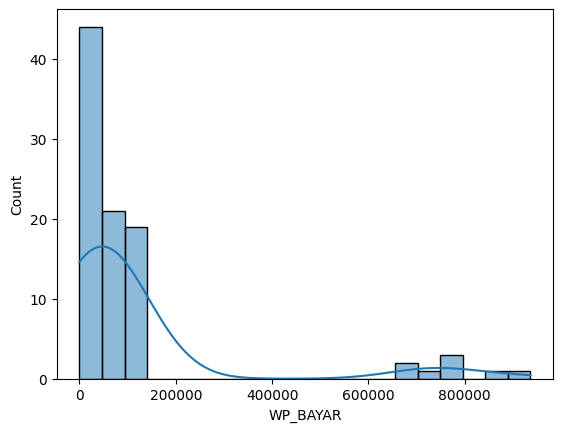

In [65]:
sns.histplot(df["WP_BAYAR"], kde=True)
plt.show()

#### b. Tren Penerimaan Pajak

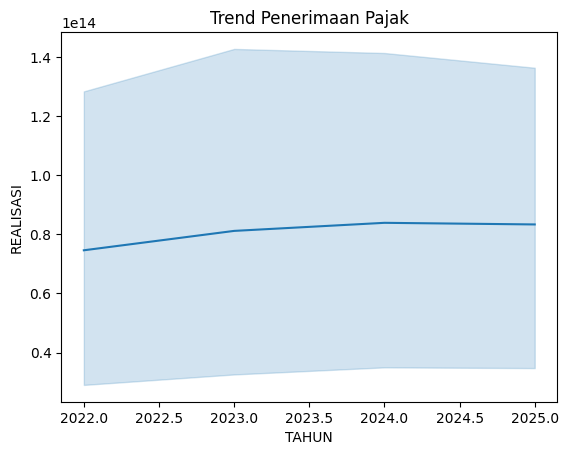

In [66]:
sns.lineplot(data=df, x="TAHUN", y="REALISASI")
plt.title("Trend Penerimaan Pajak")
plt.show()

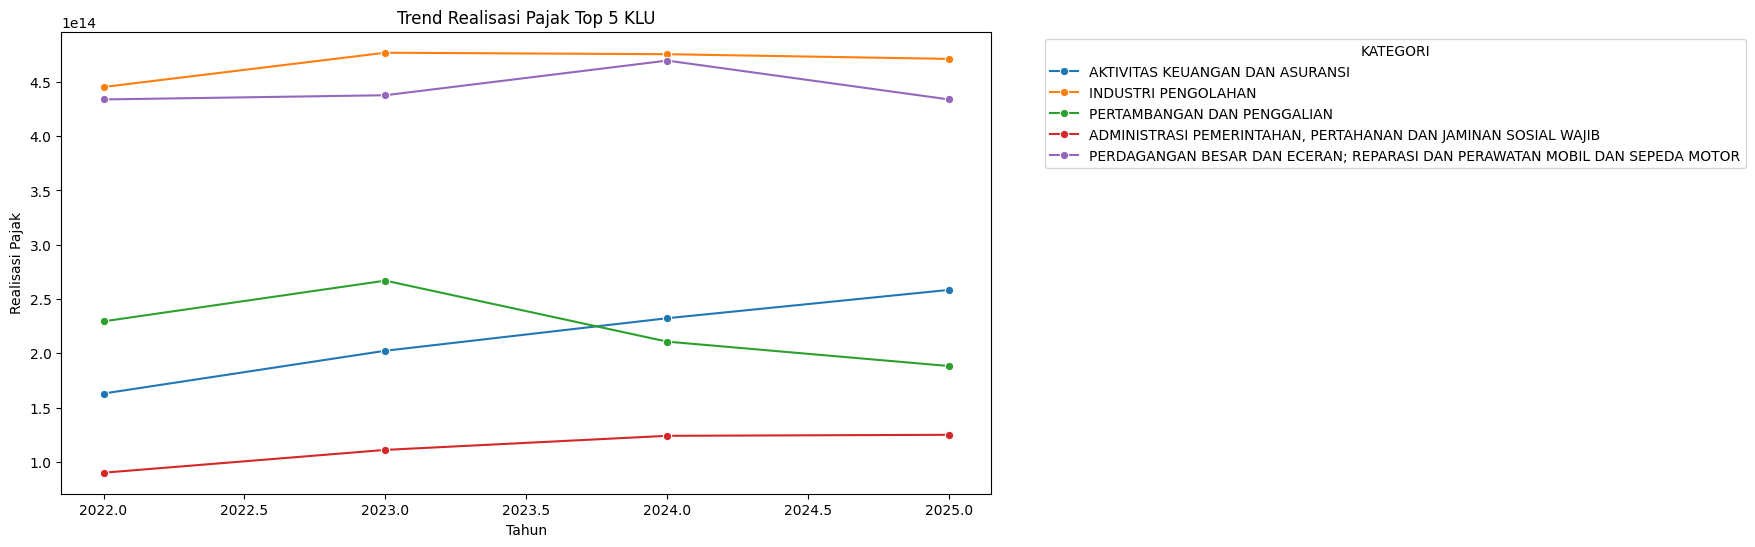

In [67]:
top_klu = df.groupby("KATEGORI")["REALISASI"].sum().nlargest(5).index
df_top = df[df["KATEGORI"].isin(top_klu)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_top,
    x="TAHUN",
    y="REALISASI",
    hue="KATEGORI",
    marker="o"
)

plt.title("Trend Realisasi Pajak Top 5 KLU")
plt.xlabel("Tahun")
plt.ylabel("Realisasi Pajak")

plt.legend(title="KATEGORI", bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()

#### c. Hubungan WP Bayar dan Penerimaan

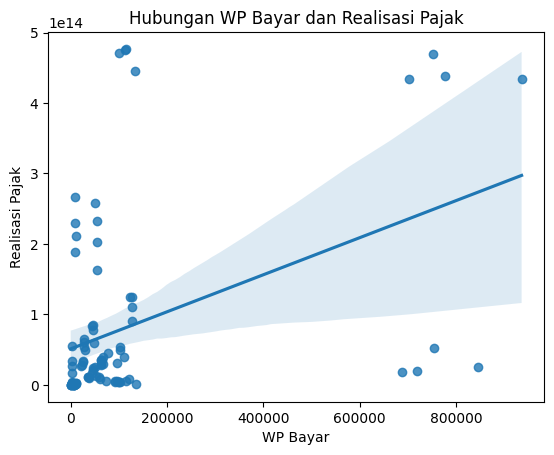

In [68]:
sns.regplot(data=df, x="WP_BAYAR", y="REALISASI")

plt.title("Hubungan WP Bayar dan Realisasi Pajak")
plt.xlabel("WP Bayar")
plt.ylabel("Realisasi Pajak")

plt.show()

### 5. Modelling

#### A. Clustering

#### 01. Memilih Feature

In [69]:
features_cl = df[[
    "COVERAGE_RATIO",
    "GROWTH_WP",
    "GROWTH_PENERIMAAN",
    "TAX_PER_WP"
]].dropna()

#### 02. Standardisasi

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(features_cl)

#### 03. K-MEANS Clustering

In [71]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

features_cl["CLUSTER"] = clusters

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### 04. Visualisasi Cluster

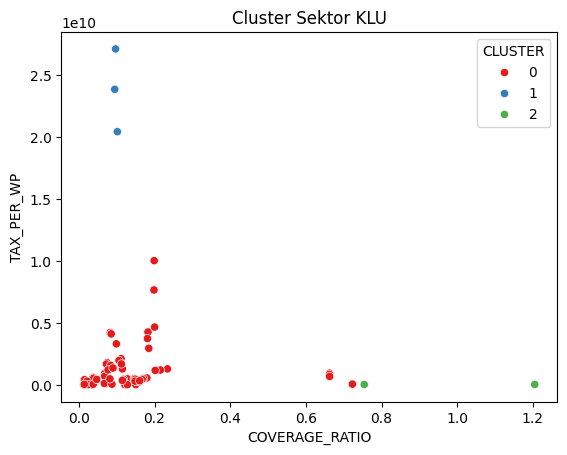

In [72]:
sns.scatterplot(
    data=features_cl,
    x="COVERAGE_RATIO",
    y="TAX_PER_WP",
    hue="CLUSTER",
    palette="Set1"
)

plt.title("Cluster Sektor KLU")
plt.show()

#### 06. Evaluasi Model K-MEANS Clustering

In [73]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.642694413808985


#### B. Regresi

#### 01. Memilih Feature

In [74]:
features_rg = [
    "POPULASI_WP",
    "WP_BAYAR",
    "COVERAGE_RATIO",
    "GDP",
    "TAX_PER_WP"
]

X = df[features_rg]

y = df["REALISASI"]

#### 02. Split Data Train dan Test

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 03. Train Data dengan Random Forest

In [76]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### 04. Prediksi Data Test

In [77]:
y_pred = model.predict(X_test)

#### 05. Visualisasi

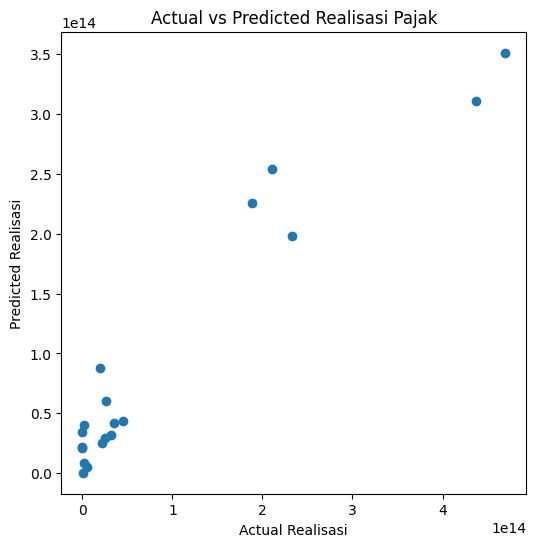

In [78]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Realisasi")
plt.ylabel("Predicted Realisasi")

plt.title("Actual vs Predicted Realisasi Pajak")

plt.show()

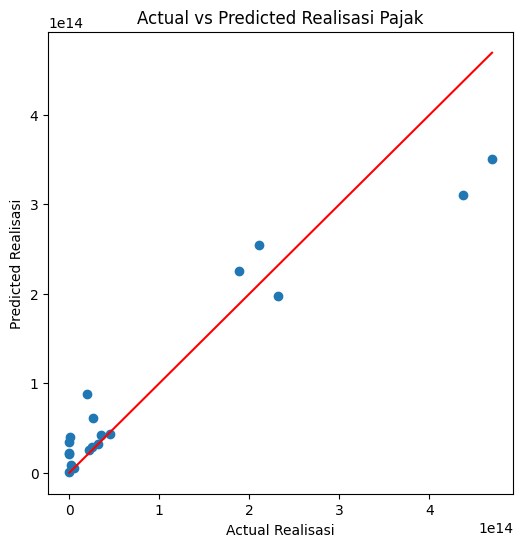

In [79]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Realisasi")
plt.ylabel("Predicted Realisasi")
plt.title("Actual vs Predicted Realisasi Pajak")

plt.show()

In [80]:
# Tampilkan hasil prediksi tiap KLU

df["PREDIKSI_REALISASI_2026"] = model.predict(X)

df_2025 = df[df["TAHUN"] == 2025]

df_2025[[
    "KODE_KLU","TAHUN","REALISASI","PREDIKSI_REALISASI_2026"
]].style.format({
    "REALISASI": "{:,.0f}",
    "PREDIKSI_REALISASI_2026": "{:,.0f}"
})

,KODE_KLU,TAHUN,REALISASI,PREDIKSI_REALISASI_2026
0,X,2025,"1,392,521,524,955","40,006,147,451,267"
1,R,2025,"2,523,445,974,688","2,446,386,203,771"
2,H,2025,"83,287,856,128,912","77,269,575,043,434"
3,U,2025,"-34,212,706,975","699,817,643,419"
4,P,2025,"5,328,501,310,754","5,485,823,759,411"
5,K,2025,"258,417,696,405,375","215,071,330,015,781"
6,I,2025,"11,944,316,270,323","11,186,741,332,733"
7,M,2025,"35,021,636,704,191","34,178,336,818,210"
8,Q,2025,"11,322,731,638,653","11,141,745,071,957"
9,D,2025,"55,358,134,003,589","85,357,953,467,013"


In [81]:
top_klu = df.groupby("KODE_KLU")["REALISASI"].sum().nlargest(5).index

# Filter dataset
df_top = df[df["KODE_KLU"].isin(top_klu)]

#Buat Dataset Prediksi Tahun 2026
df_2026 = df[df["TAHUN"] == 2025].copy()

df_2026["TAHUN"] = 2026
df_2026["REALISASI"] = df_2026["PREDIKSI_REALISASI_2026"]

# Gabungkan dataset
df_ts = pd.concat([df, df_2026])

# Filter KLU tertentu yg akna ditampilkan
df_ts = df_ts[df_ts["KODE_KLU"].isin(top_klu)]

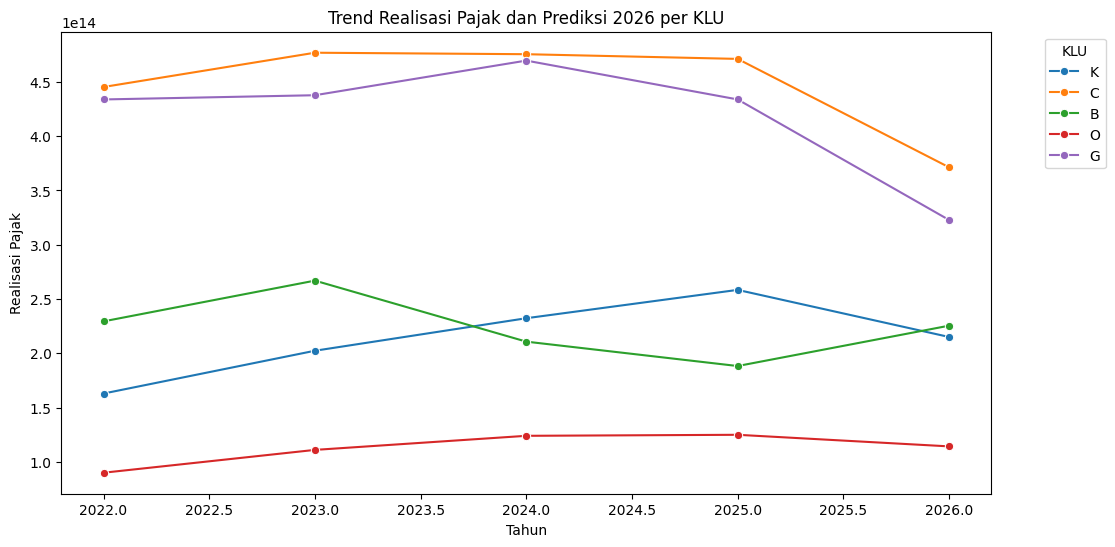

In [82]:
# Buat Grafik Timeseries
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_ts,
    x="TAHUN",
    y="REALISASI",
    hue="KODE_KLU",
    marker="o"
)

plt.title("Trend Realisasi Pajak dan Prediksi 2026 per KLU")
plt.xlabel("Tahun")
plt.ylabel("Realisasi Pajak")

plt.legend(title="KLU", bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()

#### 06. Evaluasi Model Regression

In [83]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.8869460652999863
RMSE: 48199512346100.305
